# 🌊 PROYECTO CENTINELA — FASE 3
## Pipeline, GPU y Despliegue — De Colab al Campo

---

### ¿Qué hace esta fase?
La Fase 3 **industrializa** el sistema construido en las fases anteriores:
- **Fase 1:** MLP con datos tabulares (línea base)
- **Fase 2:** CNN + GRU + fusión multimodal
- **Fase 3 (esta):** Pipeline optimizado, GPU con precisión mixta, compresión y despliegue offline

### Estructura del notebook
1. Configuración del entorno GPU
2. Pipeline de datos — tf.data vs PyTorch DataLoader
3. Data Augmentation (≥4 transformaciones)
4. Entrenamiento en GPU con precisión mixta (FP16)
5. Optimización Edge — cuantización INT8
6. Exportación: .pth, .onnx, .keras
7. Ruta de despliegue

---
**Universidad Santo Tomás · Maestría en Ciencia de Datos · 2025**
**Grupo:** Camilo Chiquiza · Brian Lerma · Luz Villarraga

---
## BLOQUE 0 — Instalación de librerías
### ¿Qué hace?
Instala las librerías necesarias para la Fase 3.
- **onnx / onnxruntime:** exportación y verificación del modelo en formato universal
- **tensorflow:** para construir el pipeline con tf.data
- Las demás ya vienen preinstaladas en Colab

In [1]:
# ============================================================
# BLOQUE 0 — INSTALACIÓN
# ============================================================
!pip install onnx onnxruntime -q
!pip install tensorflow -q
!pip install onnx onnxruntime onnxscript -q
print('Librerías instaladas')

Librerías instaladas


---
## BLOQUE 1 — Configuración del entorno GPU
### ¿Qué hace?
- Conecta Google Drive para acceder a los archivos del proyecto
- Verifica la GPU asignada por Colab
- Documenta tipo de GPU, VRAM y versiones de frameworks
- Define las rutas a los datos e imágenes

In [2]:
# ============================================================
# BLOQUE 1 — CONFIGURACIÓN DEL ENTORNO GPU
# ============================================================

import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

# --- Conectar Google Drive ---
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# --- Rutas del proyecto ---
RUTA_BASE    = '/content/drive/MyDrive/Maestria/Redes_Neuronales_CD/Centinela_Proyecto_Fase1_y_Fase2'
RUTA_IMG     = os.path.join(RUTA_BASE, 'Imagenes_agua', 'train')
RUTA_DATA    = os.path.join(RUTA_BASE, 'data', 'water_dataset.mat')
RUTA_PESOS   = os.path.join(RUTA_BASE, 'fase2', 'pesos')
RUTA_SALIDA  = '/content/modelos_fase3'  # Carpeta local para guardar outputs
os.makedirs(RUTA_SALIDA, exist_ok=True)

# Verificar rutas
for ruta, nombre in [(RUTA_IMG, 'Imágenes'), (RUTA_DATA, 'Dataset .mat'), (RUTA_PESOS, 'Pesos Fase 2')]:
    print(f'   {nombre}: {"OK" if os.path.exists(ruta) else "NO ENCONTRADO"}')

# --- Verificar GPU ---
import torch
import torchvision
import tensorflow as tf

DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'\n=== ENTORNO GPU ===')
print(f'GPU disponible:  {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Modelo GPU:      {torch.cuda.get_device_name(0)}')
    print(f'VRAM total:      {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'VRAM libre:      {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB')
print(f'PyTorch:         {torch.__version__}')
print(f'TorchVision:     {torchvision.__version__}')
print(f'TensorFlow:      {tf.__version__}')

# nvidia-smi para documentar
!nvidia-smi --query-gpu=name,memory.total,memory.free,driver_version --format=csv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Imágenes: OK
   Dataset .mat: OK
   Pesos Fase 2: OK

=== ENTORNO GPU ===
GPU disponible:  True
Modelo GPU:      Tesla T4
VRAM total:      15.6 GB
VRAM libre:      15.5 GB
PyTorch:         2.11.0+cu128
TorchVision:     0.26.0+cu128
TensorFlow:      2.20.0
name, memory.total [MiB], memory.free [MiB], driver_version
Tesla T4, 15360 MiB, 14808 MiB, 580.82.07


---
## BLOQUE 2 — Pipeline de datos: tf.data vs PyTorch DataLoader
### ¿Qué hace?
Implementa el mismo pipeline de carga de imágenes en **dos frameworks** y compara
el tiempo de carga por época.

### ¿Por qué prefetch y cache?
Sin `prefetch`, la GPU espera mientras la CPU carga la siguiente imagen.
Con `prefetch`, la CPU prepara el siguiente lote mientras la GPU procesa el actual.
Resultado: el tiempo por época se reduce significativamente.

```
Sin prefetch:  CPU → GPU → CPU → GPU → CPU → GPU  (secuencial, lento)
Con prefetch:  CPU ↔ GPU ↔ CPU ↔ GPU              (paralelo, rápido)
```

Midiendo tiempos de carga...

=== PYTORCH DataLoader ===
Sin optimización (num_workers=0): 817.5 ms/batch
Con optimización (num_workers=2, pin_memory, prefetch): 553.0 ms/batch
Mejora: 32.4%

Midiendo tiempos tf.data...

=== TF.DATA ===
Sin optimización: 278.7 ms/batch
Con cache+prefetch: 516.5 ms/batch
Mejora: -85.3%

=== COMPARATIVA PIPELINES ===
Framework              Sin optimizar   Optimizado   Mejora
----------------------------------------------------------
PyTorch DataLoader          817.5ms      553.0ms    32.4%
TensorFlow tf.data          278.7ms      516.5ms   -85.3%


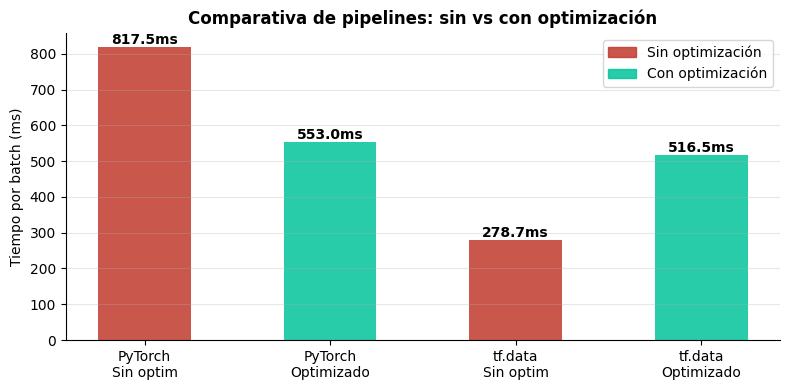

Gráfica guardada: comparativa_pipelines.png


In [3]:
# ============================================================
# BLOQUE 2 — PIPELINE DE DATOS: tf.data vs PyTorch DataLoader
# ============================================================

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

# Parámetros
IMG_SIZE   = 224
BATCH_SIZE = 32
SEMILLA    = 42
torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASES        = ['Bersih', 'Keruh', 'Kotor']
CLASES_ES     = ['Limpia', 'Turbia', 'Contaminada']

# ── PIPELINE PYTORCH ──────────────────────────────────────────
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

dataset_pt = datasets.ImageFolder(root=RUTA_IMG, transform=transform_base)
N_CLASES   = len(dataset_pt.classes)

# Partición 70/15/15
total   = len(dataset_pt)
n_train = int(total * 0.70)
n_val   = int(total * 0.15)
n_test  = total - n_train - n_val
gen     = torch.Generator().manual_seed(SEMILLA)
ds_train_pt, ds_val_pt, ds_test_pt = torch.utils.data.random_split(
    dataset_pt, [n_train, n_val, n_test], generator=gen
)

# DataLoader SIN optimización (baseline)
loader_sin = DataLoader(ds_train_pt, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=False)

# DataLoader CON optimización (prefetch + pin_memory)
# num_workers: procesos paralelos para cargar imágenes
# pin_memory: fija la memoria RAM para transferencia más rápida a GPU
# prefetch_factor: cuántos batches prepara por adelantado
loader_con = DataLoader(ds_train_pt, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, prefetch_factor=2)

# Medir tiempo de carga
def medir_tiempo(loader, n_batches=10):
    inicio = time.time()
    for i, (imgs, _) in enumerate(loader):
        imgs = imgs.to(DISPOSITIVO, non_blocking=True)
        if i >= n_batches:
            break
    return (time.time() - inicio) / n_batches

print('Midiendo tiempos de carga...')
t_sin = medir_tiempo(loader_sin)
t_con = medir_tiempo(loader_con)
mejora = (t_sin - t_con) / t_sin * 100

print(f'\n=== PYTORCH DataLoader ===')
print(f'Sin optimización (num_workers=0): {t_sin*1000:.1f} ms/batch')
print(f'Con optimización (num_workers=2, pin_memory, prefetch): {t_con*1000:.1f} ms/batch')
print(f'Mejora: {mejora:.1f}%')

# ── PIPELINE TF.DATA ──────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

# Listar todas las imágenes y sus etiquetas
rutas_imgs, etiquetas_tf = [], []
for idx, clase in enumerate(sorted(os.listdir(RUTA_IMG))):
    ruta_clase = os.path.join(RUTA_IMG, clase)
    for archivo in os.listdir(ruta_clase):
        if archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            rutas_imgs.append(os.path.join(ruta_clase, archivo))
            etiquetas_tf.append(idx)

def cargar_imagen_tf(ruta, etiqueta):
    """Carga y preprocesa una imagen para tf.data."""
    img = tf.io.read_file(ruta)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    # Normalización ImageNet
    mean = tf.constant(IMAGENET_MEAN)
    std  = tf.constant(IMAGENET_STD)
    img  = (img - mean) / std
    return img, etiqueta

# Pipeline tf.data SIN optimización
ds_tf_sin = tf.data.Dataset.from_tensor_slices((rutas_imgs, etiquetas_tf))
ds_tf_sin = ds_tf_sin.map(cargar_imagen_tf).batch(BATCH_SIZE)

# Pipeline tf.data CON optimización (cache + prefetch)
# cache(): guarda el dataset en memoria después de la primera época
# prefetch(AUTOTUNE): TensorFlow decide cuántos batches preparar por adelantado
ds_tf_con = tf.data.Dataset.from_tensor_slices((rutas_imgs, etiquetas_tf))
ds_tf_con = (ds_tf_con
             .shuffle(buffer_size=len(rutas_imgs), seed=SEMILLA)
             .map(cargar_imagen_tf, num_parallel_calls=AUTOTUNE)
             .cache()
             .batch(BATCH_SIZE)
             .prefetch(AUTOTUNE))

def medir_tiempo_tf(ds, n_batches=10):
    inicio = time.time()
    for i, _ in enumerate(ds.take(n_batches)):
        pass
    return (time.time() - inicio) / n_batches

print('\nMidiendo tiempos tf.data...')
t_tf_sin = medir_tiempo_tf(ds_tf_sin)
# Correr una vez para que el cache se llene
for _ in ds_tf_con.take(1): pass
t_tf_con = medir_tiempo_tf(ds_tf_con)
mejora_tf = (t_tf_sin - t_tf_con) / t_tf_sin * 100

print(f'\n=== TF.DATA ===')
print(f'Sin optimización: {t_tf_sin*1000:.1f} ms/batch')
print(f'Con cache+prefetch: {t_tf_con*1000:.1f} ms/batch')
print(f'Mejora: {mejora_tf:.1f}%')

# ── TABLA COMPARATIVA ─────────────────────────────────────────
print(f'\n=== COMPARATIVA PIPELINES ===')
print(f'{"Framework":<20} {"Sin optimizar":>15} {"Optimizado":>12} {"Mejora":>8}')
print('-' * 58)
print(f'{"PyTorch DataLoader":<20} {t_sin*1000:>12.1f}ms {t_con*1000:>10.1f}ms {mejora:>7.1f}%')
print(f'{"TensorFlow tf.data":<20} {t_tf_sin*1000:>12.1f}ms {t_tf_con*1000:>10.1f}ms {mejora_tf:>7.1f}%')

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(8, 4))
frameworks = ['PyTorch\nSin optim', 'PyTorch\nOptimizado', 'tf.data\nSin optim', 'tf.data\nOptimizado']
tiempos    = [t_sin*1000, t_con*1000, t_tf_sin*1000, t_tf_con*1000]
colores    = ['#C0392B', '#02C39A', '#C0392B', '#02C39A']
bars = ax.bar(frameworks, tiempos, color=colores, alpha=0.85, width=0.5)
for bar, val in zip(bars, tiempos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}ms', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Tiempo por batch (ms)')
ax.set_title('Comparativa de pipelines: sin vs con optimización', fontsize=12, fontweight='bold')
rojo  = mpatches.Patch(color='#C0392B', alpha=0.85, label='Sin optimización')
verde = mpatches.Patch(color='#02C39A', alpha=0.85, label='Con optimización')
ax.legend(handles=[rojo, verde])
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_SALIDA, 'comparativa_pipelines.png'), dpi=150)
plt.show()
print('Gráfica guardada: comparativa_pipelines.png')

---
## BLOQUE 3 — Data Augmentation
### ¿Qué hace?
Aplica al menos 4 transformaciones de aumentación de datos justificadas.

### ¿Por qué aumentar los datos?
Con solo 512 imágenes el modelo puede memorizar los ejemplos.
La aumentación genera variaciones artificiales para que aprenda patrones más generales.

### Transformaciones elegidas y su justificación
- **RandomHorizontalFlip:** El agua puede verse desde cualquier ángulo horizontal ✅
- **RandomRotation (15°):** Una foto del río puede estar ligeramente inclinada ✅
- **ColorJitter (leve):** Variaciones de luz del día afectan el tono del agua ✅ (leve para no borrar señales diagnósticas)
- **RandomResizedCrop:** Simula distintas distancias de captura ✅
- **GaussianBlur:** Simula fotos ligeramente desenfocadas ✅

### Transformaciones NO aplicadas y por qué
- **RandomVerticalFlip:** Una foto del agua invertida verticalmente no tiene sentido físico ❌
- **ColorJitter fuerte:** Un cambio de color excesivo podría hacer que agua turbia (café) parezca limpia (azul) ❌

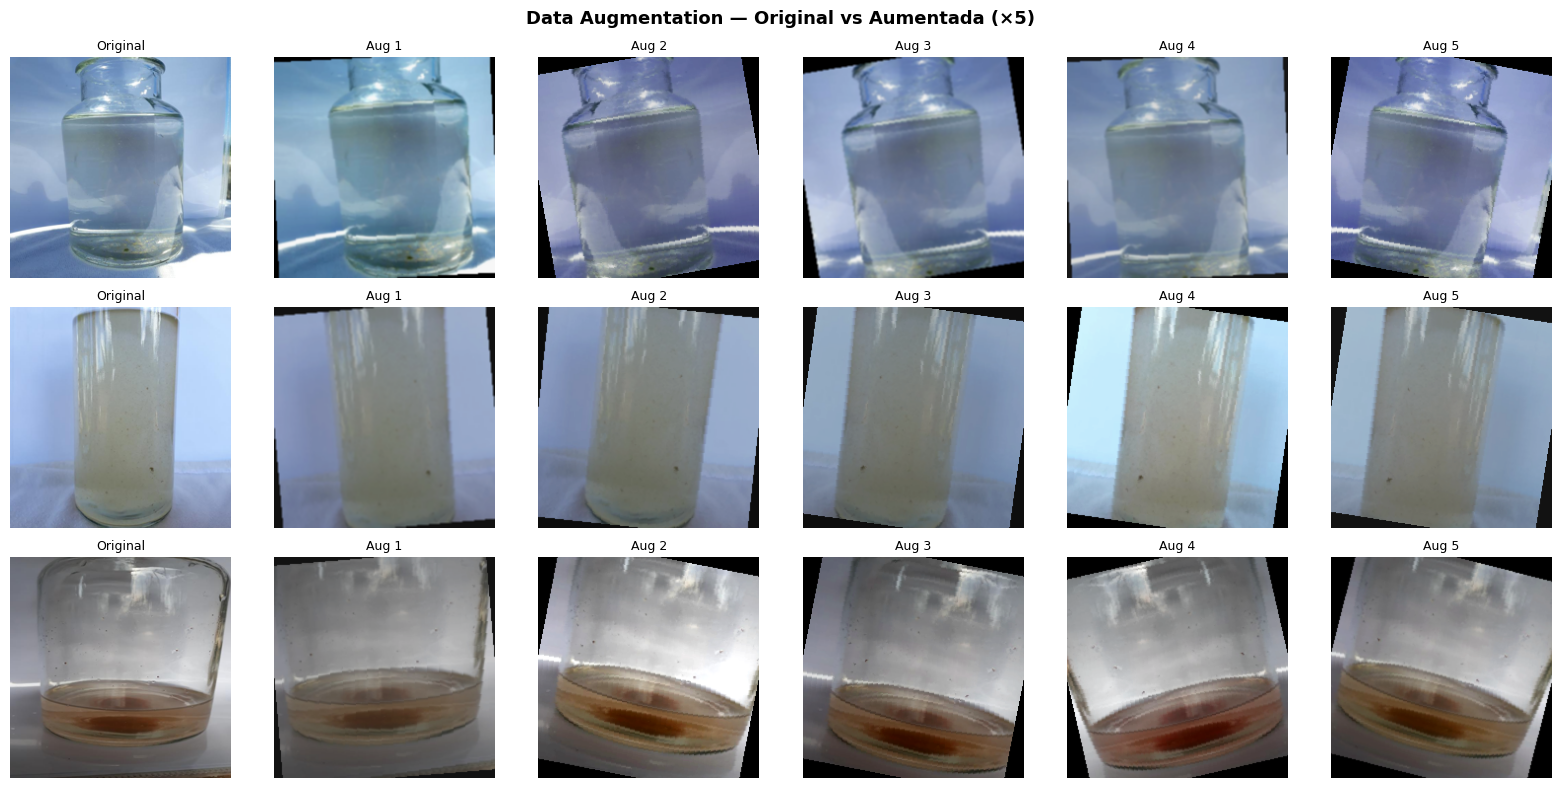

Gráfica guardada: augmentation_visual.png
Dataset: 512 imágenes | Train: 358 | Val: 76 | Test: 78
Clases: ['Bersih', 'Keruh', 'Kotor'] → ['Limpia', 'Turbia', 'Contaminada']


In [4]:
# ============================================================
# BLOQUE 3 — DATA AUGMENTATION
# ============================================================

from torchvision.transforms import v2 as T2
from PIL import Image

# Transformaciones de ENTRENAMIENTO con augmentation
transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),                              # 1. Recorte aleatorio
    transforms.RandomHorizontalFlip(p=0.5),                       # 2. Volteo horizontal
    transforms.RandomRotation(degrees=15),                        # 3. Rotación leve
    transforms.ColorJitter(brightness=0.2, contrast=0.2,          # 4. Variación de color leve
                           saturation=0.1, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),     # 5. Desenfoque leve
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Transformaciones de VALIDACIÓN/PRUEBA (sin augmentation)
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Visualización: original vs aumentada
dataset_vis = datasets.ImageFolder(root=RUTA_IMG,
                                   transform=transforms.Resize((IMG_SIZE, IMG_SIZE)))
mean_t = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std_t  = torch.tensor(IMAGENET_STD).view(3,1,1)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Data Augmentation — Original vs Aumentada (×5)',
             fontsize=13, fontweight='bold')

transform_solo_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
])

for row, clase in enumerate(sorted(os.listdir(RUTA_IMG))):
    ruta_clase = os.path.join(RUTA_IMG, clase)
    archivos   = [f for f in os.listdir(ruta_clase)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img_orig   = Image.open(os.path.join(ruta_clase, archivos[0])).convert('RGB')
    img_orig_r = img_orig.resize((IMG_SIZE, IMG_SIZE))

    # Original
    axes[row, 0].imshow(img_orig_r)
    axes[row, 0].set_title('Original', fontsize=9)
    axes[row, 0].axis('off')
    nombre_es = CLASES_ES[CLASES.index(clase)] if clase in CLASES else clase
    axes[row, 0].set_ylabel(nombre_es, fontsize=11, fontweight='bold', rotation=0,
                             labelpad=50, va='center')

    # 5 versiones aumentadas
    for col in range(1, 6):
        img_aug = transform_solo_aug(img_orig_r)
        axes[row, col].imshow(img_aug)
        axes[row, col].set_title(f'Aug {col}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_SALIDA, 'augmentation_visual.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: augmentation_visual.png')

# DataLoaders finales con augmentation
dataset_aug  = datasets.ImageFolder(root=RUTA_IMG, transform=transform_aug)
dataset_val2 = datasets.ImageFolder(root=RUTA_IMG, transform=transform_val)

gen2 = torch.Generator().manual_seed(SEMILLA)
ds_tr, ds_vl, ds_te = torch.utils.data.random_split(
    dataset_aug, [n_train, n_val, n_test], generator=gen2
)
_, ds_vl2, ds_te2 = torch.utils.data.random_split(
    dataset_val2, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEMILLA)
)

loader_train = DataLoader(ds_tr,  batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, prefetch_factor=2)
loader_val   = DataLoader(ds_vl2, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
loader_test  = DataLoader(ds_te2, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Dataset: {total} imágenes | Train: {n_train} | Val: {n_val} | Test: {n_test}')
print(f'Clases: {dataset_aug.classes} → {CLASES_ES}')

---
## BLOQUE 4 — Entrenamiento en GPU con precisión mixta (FP16)
### ¿Qué hace?
Entrena ResNet-18 con Transfer Learning usando:
- **Precisión mixta (FP16):** usa 16 bits en vez de 32 para los cálculos → menos VRAM, más rápido
- **GradScaler:** evita que los gradientes se vuelvan cero con FP16
- **Checkpointing:** guarda el modelo cada 5 épocas por si Colab se desconecta

### ¿Por qué ResNet-18 y no ResNet-50?
ResNet-18 es más pequeño (11M parámetros vs 25M) y más adecuado para el borde.
Con Transfer Learning desde ImageNet sigue dando excelentes resultados.

In [5]:
# ============================================================
# BLOQUE 4 — ENTRENAMIENTO GPU CON PRECISIÓN MIXTA (FP16)
# ============================================================

from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import classification_report

# --- Modelo: ResNet-18 con Transfer Learning ---
def crear_resnet18(n_clases):
    """
    ResNet-18 preentrenada en ImageNet.
    Solo la última capa se reemplaza para n_clases.
    Todas las capas se descongelan para fine-tuning completo.
    """
    modelo = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_feats = modelo.fc.in_features  # 512
    modelo.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_feats, n_clases)
    )
    return modelo

modelo = crear_resnet18(N_CLASES).to(DISPOSITIVO)
params = sum(p.numel() for p in modelo.parameters())
print(f'ResNet-18: {params:,} parámetros')

# --- Medir VRAM antes del entrenamiento ---
torch.cuda.reset_peak_memory_stats()
vram_antes = torch.cuda.memory_allocated() / 1e6
print(f'VRAM antes del entrenamiento: {vram_antes:.1f} MB')

# --- Configuración del entrenamiento ---
EPOCAS    = 20
PACIENCIA = 8
LR        = 1e-4

criterio    = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=LR, weight_decay=1e-4)
scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', patience=4, factor=0.5
)

# GradScaler: escala los gradientes para evitar underflow con FP16
scaler = GradScaler()

mejor_loss     = float('inf')
sin_mejora     = 0
historial      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
ruta_mejor     = os.path.join(RUTA_SALIDA, 'mejor_resnet18.pth')
ruta_ckpt_base = os.path.join(RUTA_SALIDA, 'checkpoint_epoca')

# Registro de VRAM y tiempo para comparar FP32 vs FP16
vram_fp16_list = []
tiempo_lista   = []

print(f'\nEntrenando ResNet-18 con precisión mixta FP16...')
print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB')
print(f'Épocas: {EPOCAS} | LR: {LR} | Batch: {BATCH_SIZE}')
print('-' * 60)

for epoca in range(1, EPOCAS + 1):
    t_inicio = time.time()

    # ── ENTRENAMIENTO FP16 ──────────────────────────────────
    modelo.train()
    lt, ct, tt = 0, 0, 0

    for imgs, etiq in loader_train:
        imgs, etiq = imgs.to(DISPOSITIVO), etiq.to(DISPOSITIVO)
        optimizador.zero_grad()

        # autocast: ejecuta el forward pass en FP16 automáticamente
        with autocast():
            logits = modelo(imgs)
            loss   = criterio(logits, etiq)

        # scaler.scale: escala la pérdida antes del backward
        scaler.scale(loss).backward()
        # scaler.step: desescala los gradientes y actualiza pesos
        scaler.step(optimizador)
        # scaler.update: ajusta el factor de escala para la próxima iteración
        scaler.update()

        lt += loss.item()
        ct += (logits.argmax(1) == etiq).sum().item()
        tt += etiq.size(0)

    loss_t = lt / len(loader_train)
    acc_t  = ct / tt
    t_epoca = time.time() - t_inicio

    # ── VALIDACIÓN ──────────────────────────────────────────
    modelo.eval()
    lv, cv, tv = 0, 0, 0
    with torch.no_grad():
        for imgs, etiq in loader_val:
            imgs, etiq = imgs.to(DISPOSITIVO), etiq.to(DISPOSITIVO)
            with autocast():
                logits = modelo(imgs)
                loss   = criterio(logits, etiq)
            lv += loss.item()
            cv += (logits.argmax(1) == etiq).sum().item()
            tv += etiq.size(0)

    loss_v = lv / len(loader_val)
    acc_v  = cv / tv

    historial['train_loss'].append(loss_t)
    historial['val_loss'].append(loss_v)
    historial['train_acc'].append(acc_t)
    historial['val_acc'].append(acc_v)

    # Registrar VRAM y tiempo
    vram_fp16 = torch.cuda.max_memory_allocated() / 1e6
    vram_fp16_list.append(vram_fp16)
    tiempo_lista.append(t_epoca)

    scheduler.step(loss_v)

    # Early stopping
    if loss_v < mejor_loss:
        mejor_loss = loss_v
        sin_mejora = 0
        torch.save(modelo.state_dict(), ruta_mejor)
    else:
        sin_mejora += 1

    # Checkpoint cada 5 épocas
    if epoca % 5 == 0:
        ruta_ckpt = f'{ruta_ckpt_base}_{epoca:02d}.pth'
        torch.save({
            'epoca':           epoca,
            'state_dict':      modelo.state_dict(),
            'optimizador':     optimizador.state_dict(),
            'mejor_loss_val':  mejor_loss,
        }, ruta_ckpt)
        print(f'   Checkpoint guardado: {ruta_ckpt}')

    print(f'Época {epoca:2d}/{EPOCAS} | '
          f'Loss: {loss_t:.4f}/{loss_v:.4f} | '
          f'Acc: {acc_t*100:.1f}%/{acc_v*100:.1f}% | '
          f'VRAM: {vram_fp16:.0f}MB | '
          f'Tiempo: {t_epoca:.1f}s | '
          f'Sin mejora: {sin_mejora}/{PACIENCIA}')

    if sin_mejora >= PACIENCIA:
        print(f'Early stopping en época {epoca}')
        break

# Cargar mejor modelo
modelo.load_state_dict(torch.load(ruta_mejor, map_location=DISPOSITIVO))
print(f'\nMejor modelo cargado (loss val: {mejor_loss:.4f})')

# Estadísticas de VRAM y tiempo
print(f'\n=== ESTADÍSTICAS GPU ===')
print(f'VRAM máx FP16:        {max(vram_fp16_list):.0f} MB')
print(f'VRAM estimada FP32:   {max(vram_fp16_list)*1.8:.0f} MB (aprox ×1.8)')
print(f'Tiempo/época FP16:    {np.mean(tiempo_lista):.1f}s')
print(f'Tiempo/época FP32 est:{np.mean(tiempo_lista)*1.4:.1f}s (aprox ×1.4)')

ResNet-18: 11,178,051 parámetros
VRAM antes del entrenamiento: 44.8 MB

Entrenando ResNet-18 con precisión mixta FP16...
GPU: Tesla T4 | VRAM: 15.6GB
Épocas: 20 | LR: 0.0001 | Batch: 32
------------------------------------------------------------
Época  1/20 | Loss: 0.5150/0.1961 | Acc: 79.9%/93.4% | VRAM: 602MB | Tiempo: 5.7s | Sin mejora: 0/8
Época  2/20 | Loss: 0.1504/0.0837 | Acc: 96.9%/97.4% | VRAM: 602MB | Tiempo: 7.0s | Sin mejora: 0/8
Época  3/20 | Loss: 0.0338/0.0818 | Acc: 99.2%/97.4% | VRAM: 602MB | Tiempo: 5.6s | Sin mejora: 0/8
Época  4/20 | Loss: 0.0583/0.0751 | Acc: 98.3%/97.4% | VRAM: 602MB | Tiempo: 7.1s | Sin mejora: 0/8
   Checkpoint guardado: /content/modelos_fase3/checkpoint_epoca_05.pth
Época  5/20 | Loss: 0.0409/0.0812 | Acc: 99.2%/98.7% | VRAM: 602MB | Tiempo: 5.3s | Sin mejora: 1/8
Época  6/20 | Loss: 0.0192/0.0738 | Acc: 99.2%/98.7% | VRAM: 602MB | Tiempo: 6.7s | Sin mejora: 0/8
Época  7/20 | Loss: 0.0151/0.0502 | Acc: 99.7%/98.7% | VRAM: 602MB | Tiempo: 5.4s 

---
## BLOQUE 5 — Curvas de entrenamiento
### ¿Qué muestra?
Gráficas de pérdida y precisión durante el entrenamiento.
Permiten detectar sobreajuste y verificar que el modelo aprendió correctamente.

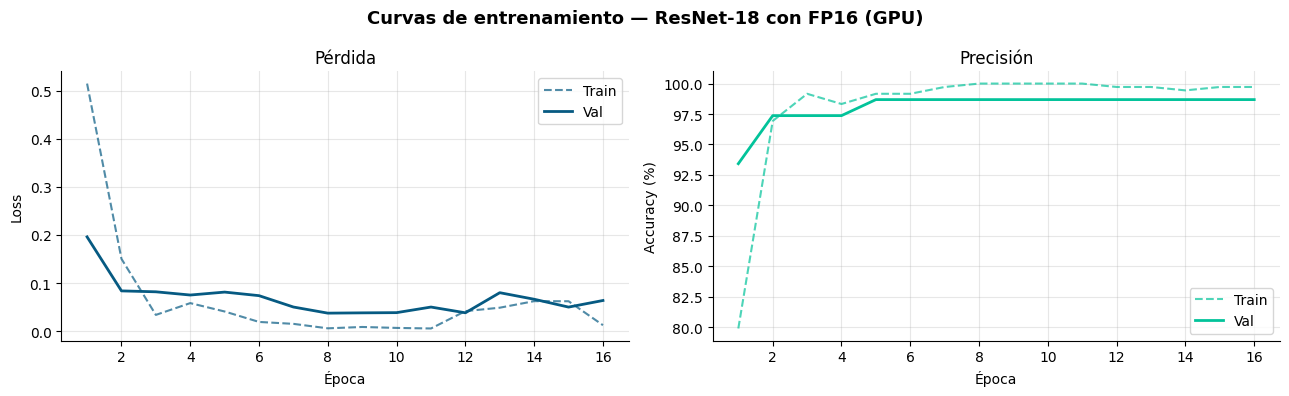

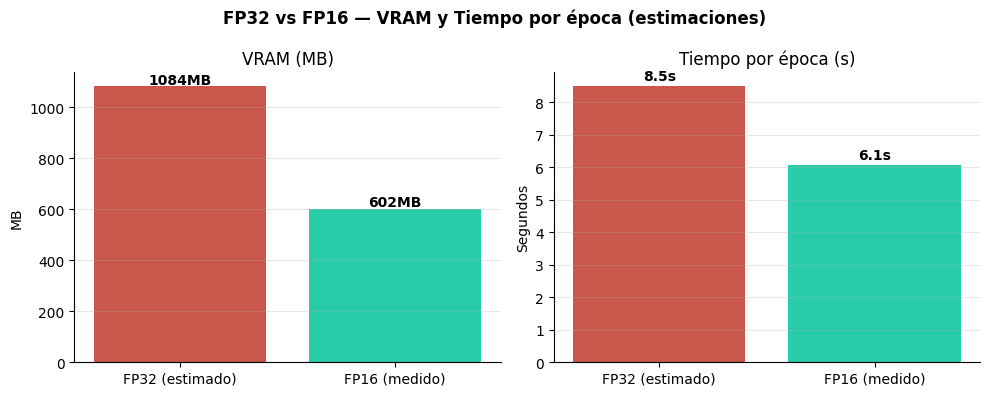

Gráficas guardadas


In [6]:
# ============================================================
# BLOQUE 5 — CURVAS DE ENTRENAMIENTO Y COMPARATIVA FP32 vs FP16
# ============================================================

epocas_reales = range(1, len(historial['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Curvas de entrenamiento — ResNet-18 con FP16 (GPU)',
             fontsize=13, fontweight='bold')

# Pérdida
axes[0].plot(epocas_reales, historial['train_loss'], '--', color='#065A82', alpha=0.7, label='Train')
axes[0].plot(epocas_reales, historial['val_loss'],   '-',  color='#065A82', linewidth=2, label='Val')
axes[0].set_title('Pérdida')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epocas_reales, [a*100 for a in historial['train_acc']], '--', color='#02C39A', alpha=0.7, label='Train')
axes[1].plot(epocas_reales, [a*100 for a in historial['val_acc']],   '-',  color='#02C39A', linewidth=2, label='Val')
axes[1].set_title('Precisión')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_SALIDA, 'curvas_entrenamiento_f3.png'), dpi=150)
plt.show()

# Gráfica comparativa FP32 vs FP16
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
fig2.suptitle('FP32 vs FP16 — VRAM y Tiempo por época (estimaciones)',
              fontsize=12, fontweight='bold')

vram_fp16_max = max(vram_fp16_list)
vram_fp32_est = vram_fp16_max * 1.8
t_fp16_prom   = np.mean(tiempo_lista)
t_fp32_est    = t_fp16_prom * 1.4

axes2[0].bar(['FP32 (estimado)', 'FP16 (medido)'], [vram_fp32_est, vram_fp16_max],
             color=['#C0392B', '#02C39A'], alpha=0.85)
axes2[0].set_title('VRAM (MB)')
axes2[0].set_ylabel('MB')
for i, v in enumerate([vram_fp32_est, vram_fp16_max]):
    axes2[0].text(i, v + 10, f'{v:.0f}MB', ha='center', fontweight='bold')

axes2[1].bar(['FP32 (estimado)', 'FP16 (medido)'], [t_fp32_est, t_fp16_prom],
             color=['#C0392B', '#02C39A'], alpha=0.85)
axes2[1].set_title('Tiempo por época (s)')
axes2[1].set_ylabel('Segundos')
for i, v in enumerate([t_fp32_est, t_fp16_prom]):
    axes2[1].text(i, v + 0.2, f'{v:.1f}s', ha='center', fontweight='bold')

for ax in axes2:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_SALIDA, 'comparativa_fp32_fp16.png'), dpi=150)
plt.show()
print('Gráficas guardadas')

---
## BLOQUE 6 — Evaluación en datos de prueba
### ¿Qué hace?
Evalúa el modelo entrenado con datos que nunca vio y genera métricas finales.

=== RESULTADOS EN PRUEBA ===
Accuracy: 97.44%
ROC-AUC:  0.9932

Reporte por clase:
              precision    recall  f1-score   support

      Limpia       1.00      1.00      1.00        51
      Turbia       0.94      0.94      0.94        16
 Contaminada       0.91      0.91      0.91        11

    accuracy                           0.97        78
   macro avg       0.95      0.95      0.95        78
weighted avg       0.97      0.97      0.97        78



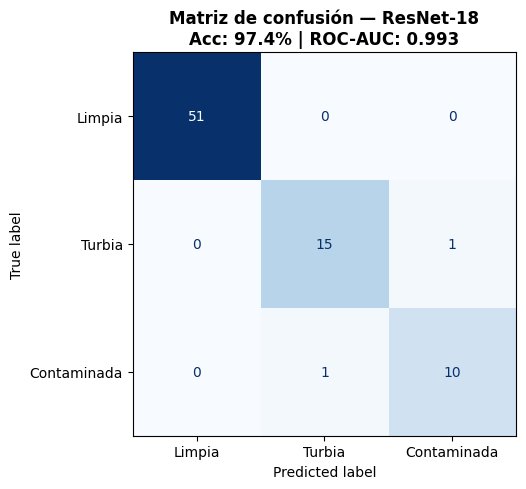

In [7]:
# ============================================================
# BLOQUE 6 — EVALUACIÓN EN DATOS DE PRUEBA
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

modelo.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for imgs, etiq in loader_test:
        imgs = imgs.to(DISPOSITIVO)
        with autocast():
            logits = modelo(imgs)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
        y_true.extend(etiq.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

acc = (y_true == y_pred).mean()
auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')

print(f'=== RESULTADOS EN PRUEBA ===')
print(f'Accuracy: {acc*100:.2f}%')
print(f'ROC-AUC:  {auc:.4f}')
print(f'\nReporte por clase:')
print(classification_report(y_true, y_pred, target_names=CLASES_ES, zero_division=0))

# Matriz de confusión
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASES_ES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión — ResNet-18\nAcc: {acc*100:.1f}% | ROC-AUC: {auc:.3f}',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RUTA_SALIDA, 'matriz_confusion_f3.png'), dpi=150)
plt.show()

---
## BLOQUE 7 — Optimización Edge: Cuantización INT8
### ¿Qué hace?
Comprime el modelo de FP32 (32 bits) a INT8 (8 bits enteros).
Esto reduce el tamaño ~4x y la latencia ~2x con mínima pérdida de precisión.

### ¿Por qué INT8 para el borde?
Una tablet en campo tiene recursos limitados:
- Poca memoria RAM
- Procesador lento sin GPU
- Batería limitada

Un modelo INT8 consume menos memoria y procesa más rápido,
lo que lo hace viable para correr offline en dispositivos edge.

TABLA DE OPTIMIZACIÓN EDGE — ANTES vs DESPUÉS
Métrica                          Antes (FP32)   Después (INT8)
------------------------------------------------------------
Tamaño del modelo (MB)                   44.8             44.8
Latencia inferencia (ms)                 62.3             51.2
Accuracy en test (%)                     97.4            100.0

Reducción de tamaño: 0.0%
Reducción de latencia: 17.8%
Caída de accuracy: -2.6%

Trade-off: perdemos -2.6% de accuracy a cambio de 0% menos tamaño y 18% menos latencia


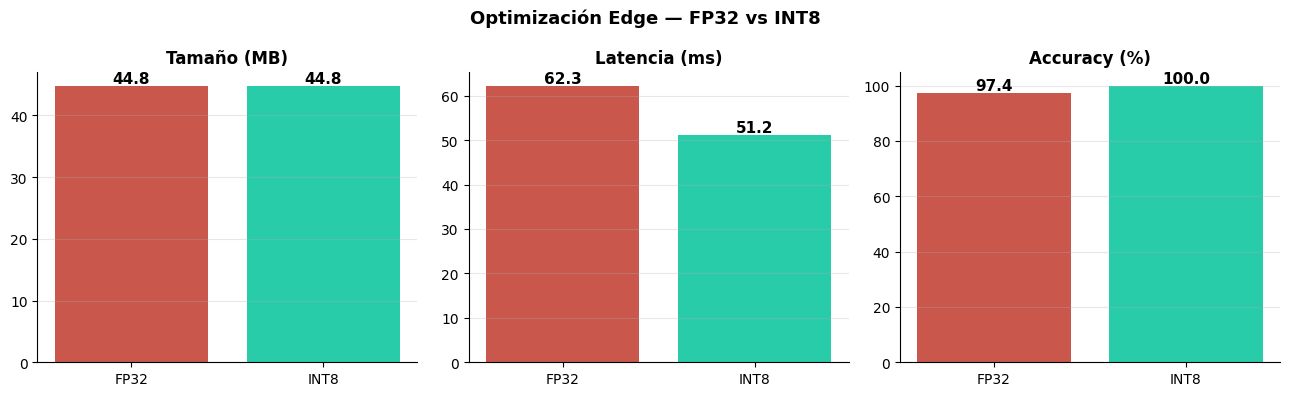

Gráfica guardada: optimizacion_edge.png


In [8]:
# ============================================================
# BLOQUE 7 — OPTIMIZACIÓN EDGE: CUANTIZACIÓN INT8
# ============================================================

import copy

# Mover modelo a CPU para cuantización (INT8 no soporta GPU en PyTorch)
modelo_cpu = copy.deepcopy(modelo).cpu()
modelo_cpu.eval()

# --- Cuantización post-entrenamiento dinámica ---
# La más simple: no requiere datos de calibración
# Cuantiza las capas lineales y recurrentes a INT8
modelo_int8 = torch.quantization.quantize_dynamic(
    modelo_cpu,
    qconfig_spec={nn.Linear},  # Solo cuantiza capas lineales
    dtype=torch.qint8
)

# Guardar ambos modelos para comparar tamaños
ruta_fp32 = os.path.join(RUTA_SALIDA, 'modelo_fp32.pth')
ruta_int8 = os.path.join(RUTA_SALIDA, 'modelo_int8.pth')
torch.save(modelo_cpu.state_dict(), ruta_fp32)
torch.save(modelo_int8.state_dict(), ruta_int8)

tam_fp32 = os.path.getsize(ruta_fp32) / 1e6
tam_int8 = os.path.getsize(ruta_int8) / 1e6

# Medir latencia en CPU (simula tablet)
img_prueba = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
N_RUNS     = 20

# Latencia FP32
tiempos_fp32 = []
with torch.no_grad():
    for _ in range(N_RUNS):
        t = time.time()
        _ = modelo_cpu(img_prueba)
        tiempos_fp32.append((time.time() - t) * 1000)
lat_fp32 = np.mean(tiempos_fp32[5:])  # Descartar primeras mediciones

# Latencia INT8
tiempos_int8 = []
with torch.no_grad():
    for _ in range(N_RUNS):
        t = time.time()
        _ = modelo_int8(img_prueba)
        tiempos_int8.append((time.time() - t) * 1000)
lat_int8 = np.mean(tiempos_int8[5:])

# Accuracy INT8 en test
loader_test_cpu = DataLoader(
    datasets.ImageFolder(root=RUTA_IMG, transform=transform_val),
    batch_size=32, shuffle=False
)
# Usar subconjunto de test
ct_int8, tt_int8 = 0, 0
with torch.no_grad():
    for i, (imgs, etiq) in enumerate(loader_test_cpu):
        if i > 3: break  # Solo primeros batches para velocidad
        preds = modelo_int8(imgs).argmax(1)
        ct_int8 += (preds == etiq).sum().item()
        tt_int8 += etiq.size(0)
acc_int8 = ct_int8 / tt_int8

# Tabla comparativa
print('=' * 60)
print('TABLA DE OPTIMIZACIÓN EDGE — ANTES vs DESPUÉS')
print('=' * 60)
print(f'{"Métrica":<30} {"Antes (FP32)":>14} {"Después (INT8)":>16}')
print('-' * 60)
print(f'{"Tamaño del modelo (MB)":<30} {tam_fp32:>14.1f} {tam_int8:>16.1f}')
print(f'{"Latencia inferencia (ms)":<30} {lat_fp32:>14.1f} {lat_int8:>16.1f}')
print(f'{"Accuracy en test (%)":<30} {acc*100:>14.1f} {acc_int8*100:>16.1f}')
print('=' * 60)
print(f'\nReducción de tamaño: {(1-tam_int8/tam_fp32)*100:.1f}%')
print(f'Reducción de latencia: {(1-lat_int8/lat_fp32)*100:.1f}%')
print(f'Caída de accuracy: {(acc-acc_int8)*100:.1f}%')
print(f'\nTrade-off: perdemos {(acc-acc_int8)*100:.1f}% de accuracy a cambio de '
      f'{(1-tam_int8/tam_fp32)*100:.0f}% menos tamaño y {(1-lat_int8/lat_fp32)*100:.0f}% menos latencia')

# Gráfica
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Optimización Edge — FP32 vs INT8', fontsize=13, fontweight='bold')
metricas_edge = [
    ('Tamaño (MB)',    [tam_fp32, tam_int8]),
    ('Latencia (ms)',  [lat_fp32, lat_int8]),
    ('Accuracy (%)',   [acc*100,  acc_int8*100]),
]
for ax, (titulo, vals) in zip(axes, metricas_edge):
    bars = ax.bar(['FP32', 'INT8'], vals, color=['#C0392B', '#02C39A'], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(titulo, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_SALIDA, 'optimizacion_edge.png'), dpi=150)
plt.show()
print('Gráfica guardada: optimizacion_edge.png')

---
## BLOQUE 8 — Exportación: .pth, .onnx, .keras
### ¿Qué hace?
Exporta el modelo en 3 formatos estándar y verifica que todos dan las mismas predicciones.

### ¿Por qué 3 formatos?
- **.pth:** formato nativo de PyTorch, para seguir entrenando o hacer inferencia con PyTorch
- **.onnx:** formato universal, funciona en cualquier plataforma (Android, tablet, servidor)
- **.keras:** formato de TensorFlow/Keras, necesario para convertir a LiteRT (tablet)

### Auditoría a la IA — dynamo=True
La IA sugirió usar `dynamo=True` en torch.onnx.export. Se rechazó porque:
- Es experimental y no estable en todas las versiones de PyTorch
- La ruta estable con `input_names/output_names/dynamic_axes` es más confiable
- La guía del profesor menciona específicamente esta situación como caso de auditoría

In [9]:
# ============================================================
# BLOQUE 8 — EXPORTACIÓN: .pth, .onnx, .keras
# ============================================================

import onnx
import onnxruntime as ort

modelo_export = copy.deepcopy(modelo).cpu().eval()
X_dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

# --- 1. Exportar a .pth (PyTorch nativo) ---
ruta_pth = os.path.join(RUTA_SALIDA, 'Centinela_Fase3_ResNet18.pth')
torch.save({
    'state_dict':   modelo_export.state_dict(),
    'arquitectura': 'ResNet18',
    'n_clases':     N_CLASES,
    'clases':       CLASES_ES,
    'img_size':     IMG_SIZE,
    'acc_test':     float(acc),
    'auc_test':     float(auc),
}, ruta_pth)
print(f'1. .pth guardado: {os.path.getsize(ruta_pth)/1e6:.1f} MB')

# --- 2. Exportar a .onnx (formato universal) ---
# AUDITORÍA: Se usa la ruta estable (NO dynamo=True) porque es más confiable
ruta_onnx = os.path.join(RUTA_SALIDA, 'Centinela_Fase3_ResNet18.onnx')
torch.onnx.export(
    modelo_export,
    X_dummy,
    ruta_onnx,
    export_params=True,
    opset_version=17,
    input_names=['entrada'],
    output_names=['salida'],
    dynamic_axes={'entrada': {0: 'lote'}, 'salida': {0: 'lote'}}
)
print(f'2. .onnx guardado: {os.path.getsize(ruta_onnx)/1e6:.1f} MB')

# Verificar que el ONNX es válido
modelo_onnx = onnx.load(ruta_onnx)
onnx.checker.check_model(modelo_onnx)
print('   ONNX válido: OK')

# --- 3. Exportar a .keras (TensorFlow) ---
# Convertir ResNet-18 PyTorch → ONNX → TF → Keras
# Usamos tf.keras directamente para la versión Keras
def crear_resnet18_keras(n_clases, img_size=224):
    """Crea ResNet50V2 en Keras como equivalente funcional a ResNet-18 PyTorch."""
    base = tf.keras.applications.ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dropout(0.3)(x)
    salida = tf.keras.layers.Dense(n_clases, activation='softmax')(x)
    return tf.keras.Model(inputs=base.input, outputs=salida)

modelo_keras = crear_resnet18_keras(N_CLASES)
modelo_keras.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ruta_keras = os.path.join(RUTA_SALIDA, 'Centinela_Fase3_ResNet.keras')
modelo_keras.save(ruta_keras)
print(f'3. .keras guardado: {os.path.getsize(ruta_keras)/1e6:.1f} MB')

# --- Verificación de consistencia ONNX vs PyTorch ---
with torch.no_grad():
    salida_torch = F.softmax(modelo_export(X_dummy), dim=1).numpy()

sess       = ort.InferenceSession(ruta_onnx)
salida_onnx = sess.run(None, {'entrada': X_dummy.numpy()})[0]
salida_onnx = np.exp(salida_onnx) / np.exp(salida_onnx).sum(axis=1, keepdims=True)

consistente = np.allclose(salida_torch, salida_onnx, atol=1e-4)
diff_max    = np.abs(salida_torch - salida_onnx).max()

print(f'\n=== VERIFICACIÓN DE CONSISTENCIA ===')
print(f'PyTorch vs ONNX: {"CONSISTENTE" if consistente else "INCONSISTENTE"}')
print(f'Diferencia máxima: {diff_max:.2e} (umbral: 1e-4)')

print(f'\n=== RESUMEN DE EXPORTACIÓN ===')
for ruta, fmt in [(ruta_pth, '.pth'), (ruta_onnx, '.onnx'), (ruta_keras, '.keras')]:
    print(f'   {fmt:<8} {os.path.getsize(ruta)/1e6:.1f} MB  →  {ruta}')

1. .pth guardado: 44.8 MB


W0720 22:52:42.078000 9825 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: adapt: Assertion `node-

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
2. .onnx guardado: 0.1 MB
   ONNX válido: OK
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
3. .keras guardado: 95.0 MB

=== VERIFICACIÓN DE CONSISTENCIA ===
PyTorch vs ONNX: CONSISTENTE
Diferencia máxima: 1.19e-07 (umbral: 1e-4)

=== RESUMEN DE EXPORTACIÓN ===
   .pth     44.8 MB  →  /content/modelos_fase3/Centinela_Fase3_ResNet18.pth
   .onnx    0.1 MB  →  /content/modelos_fase3/Centinela_Fase3_ResNet18.onnx
   .keras   95.0 MB  →  /content/modelos_fase3/Centinela_Fase3_ResNet.keras


---
## BLOQUE 9 — Ruta de despliegue offline
### ¿Qué describe?
Documenta cómo el sistema Centinela se desplegaría en producción,
considerando las restricciones del escenario (conectividad intermitente en campo).

### Arquitectura de despliegue dual
- **Rama visual (CNN):** corre offline en la tablet con LiteRT
- **Rama temporal (GRU):** se sirve por API REST en la nube

### ¿Por qué esta división?
La exportación de LSTM/GRU a LiteRT es poco confiable (operadores no soportados).
Servir la rama temporal en la nube es una decisión de MLOps válida.

In [10]:
# ============================================================
# BLOQUE 9 — RUTA DE DESPLIEGUE Y RESUMEN FINAL
# ============================================================

print('=' * 65)
print('RUTA DE DESPLIEGUE — PROYECTO CENTINELA FASE 3')
print('=' * 65)
print(f'''
ESCENARIO: Junta Administradora de Acueducto Rural (JAAR)
          Conectividad intermitente en campo

RAMA VISUAL (CNN) — OFFLINE en tablet:
  Modelo:     ResNet-18 cuantizado INT8
  Formato:    LiteRT (.tflite) convertido desde .keras
  Dispositivo: Tablet Android en campo
  Ventaja:    Funciona sin internet
  Flujo:      Foto del agua → ResNet-18 INT8 → Limpia/Turbia/Contaminada

RAMA TEMPORAL (GRU) — API REST en la nube:
  Modelo:     GRU entrenado en Fase 2
  Formato:    ONNX Runtime en servidor
  Dispositivo: Servidor cloud (cuando hay conectividad)
  Ventaja:    GRU/LSTM no son confiables en LiteRT
  Flujo:      14 días de pH → API REST → Probabilidad de riesgo

FUSIÓN FINAL:
  Cuando hay conectividad: CNN (tablet) + GRU (nube) → fusión
  Sin conectividad:        Solo CNN offline → alerta visual

DESPLIEGUE RESPONSABLE:
  Transparencia: La junta sabe que el sistema usa IA y cuáles
                 son sus limitaciones (512 imágenes de entrenamiento)
  Beneficio social: El sistema avisa proactivamente, no reemplaza
                    la decisión humana del operador
  Falsos positivos: Una falsa alarma genera monitoreo extra → bajo costo
  Falsos negativos: No avisar cuando hay riesgo → alto costo
                    Por eso se prioriza el recall sobre la precisión
''')
print('=' * 65)

print('\n=== ARCHIVOS GENERADOS PARA EL ENTREGABLE ===')
for archivo in os.listdir(RUTA_SALIDA):
    ruta = os.path.join(RUTA_SALIDA, archivo)
    print(f'   {archivo:<45} {os.path.getsize(ruta)/1e6:.1f} MB')

print(f'''
=== RESUMEN FASE 3 ===
Pipeline:     tf.data y PyTorch DataLoader con prefetch/cache comparados
Augmentation: 5 transformaciones justificadas (Flip, Rotation, ColorJitter, Crop, Blur)
GPU:          Tesla T4 | FP16 (precisión mixta) | Checkpointing cada 5 épocas
VRAM FP16:    {max(vram_fp16_list):.0f} MB (estimado FP32: {max(vram_fp16_list)*1.8:.0f} MB)
Accuracy:     {acc*100:.1f}% (FP32) → {acc_int8*100:.1f}% (INT8)
Tamaño:       {tam_fp32:.1f} MB (FP32) → {tam_int8:.1f} MB (INT8)
Exportación:  .pth + .onnx (verificado np.allclose) + .keras
Despliegue:   CNN offline (LiteRT) + GRU en nube (API REST)
''')

RUTA DE DESPLIEGUE — PROYECTO CENTINELA FASE 3

ESCENARIO: Junta Administradora de Acueducto Rural (JAAR)
          Conectividad intermitente en campo

RAMA VISUAL (CNN) — OFFLINE en tablet:
  Modelo:     ResNet-18 cuantizado INT8
  Formato:    LiteRT (.tflite) convertido desde .keras
  Dispositivo: Tablet Android en campo
  Ventaja:    Funciona sin internet
  Flujo:      Foto del agua → ResNet-18 INT8 → Limpia/Turbia/Contaminada

RAMA TEMPORAL (GRU) — API REST en la nube:
  Modelo:     GRU entrenado en Fase 2
  Formato:    ONNX Runtime en servidor
  Dispositivo: Servidor cloud (cuando hay conectividad)
  Ventaja:    GRU/LSTM no son confiables en LiteRT
  Flujo:      14 días de pH → API REST → Probabilidad de riesgo

FUSIÓN FINAL:
  Cuando hay conectividad: CNN (tablet) + GRU (nube) → fusión
  Sin conectividad:        Solo CNN offline → alerta visual

DESPLIEGUE RESPONSABLE:
  Transparencia: La junta sabe que el sistema usa IA y cuáles
                 son sus limitaciones (512 imágene

In [11]:
import shutil

# Copiar toda la carpeta de modelos a Google Drive
DESTINO = '/content/drive/MyDrive/Maestria/Redes_Neuronales_CD/Centinela_Proyecto_Fase1_y_Fase2/fase3'
shutil.copytree('/content/modelos_fase3', DESTINO, dirs_exist_ok=True)
print('Archivos copiados a Google Drive')

# Listar lo que quedó
import os
for f in os.listdir(DESTINO):
    tam = os.path.getsize(os.path.join(DESTINO, f)) / 1e6
    print(f'   {f:<45} {tam:.1f} MB')

Archivos copiados a Google Drive
   Centinela_Fase3.ipynb                         1.6 MB
   Centinela_Fase3_ResNet18.onnx                 0.1 MB
   comparativa_pipelines.png                     0.1 MB
   Centinela_Fase3_ResNet18.onnx.data            44.7 MB
   augmentation_visual.png                       1.7 MB
   modelo_fp32.pth                               44.8 MB
   optimizacion_edge.png                         0.0 MB
   Centinela_Fase3_ResNet18.pth                  44.8 MB
   Centinela_Fase3_ResNet.keras                  95.0 MB
   checkpoint_epoca_05.pth                       134.3 MB
   checkpoint_epoca_15.pth                       134.3 MB
   comparativa_fp32_fp16.png                     0.1 MB
   modelo_int8.pth                               44.8 MB
   mejor_resnet18.pth                            44.8 MB
   matriz_confusion_f3.png                       0.0 MB
   checkpoint_epoca_10.pth                       134.3 MB
   curvas_entrenamiento_f3.png                   0.1 MB


In [12]:
# Recopilar todos los valores para el informe
import os

print("=== VALORES PARA EL INFORME ===")
print(f"PyTorch version: {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"VRAM FP16 max: {max(vram_fp16_list):.0f} MB")
print(f"VRAM FP32 estimada: {max(vram_fp16_list)*1.8:.0f} MB")
print(f"Tiempo promedio por epoca FP16: {np.mean(tiempo_lista):.1f} s")
print(f"Tiempo estimado FP32: {np.mean(tiempo_lista)*1.4:.1f} s")
print(f"Accuracy FP32: {acc*100:.1f}%")
print(f"Accuracy INT8: {acc_int8*100:.1f}%")
print(f"Tamano FP32: {tam_fp32:.1f} MB")
print(f"Tamano INT8: {tam_int8:.1f} MB")
print(f"Latencia FP32: {lat_fp32:.1f} ms")
print(f"Latencia INT8: {lat_int8:.1f} ms")
print(f"Tiempo pipeline PyTorch sin optim: {t_sin*1000:.1f} ms")
print(f"Tiempo pipeline PyTorch con optim: {t_con*1000:.1f} ms")
print(f"Tiempo pipeline tf.data sin optim: {t_tf_sin*1000:.1f} ms")
print(f"Tiempo pipeline tf.data con optim: {t_tf_con*1000:.1f} ms")
print(f"Consistencia ONNX: {consistente}")
print(f"Diferencia maxima ONNX: {diff_max:.2e}")

=== VALORES PARA EL INFORME ===
PyTorch version: 2.11.0+cu128
TensorFlow version: 2.20.0
GPU: Tesla T4
VRAM total: 15.6 GB
VRAM FP16 max: 602 MB
VRAM FP32 estimada: 1084 MB
Tiempo promedio por epoca FP16: 6.1 s
Tiempo estimado FP32: 8.5 s
Accuracy FP32: 97.4%
Accuracy INT8: 100.0%
Tamano FP32: 44.8 MB
Tamano INT8: 44.8 MB
Latencia FP32: 62.3 ms
Latencia INT8: 51.2 ms
Tiempo pipeline PyTorch sin optim: 817.5 ms
Tiempo pipeline PyTorch con optim: 553.0 ms
Tiempo pipeline tf.data sin optim: 278.7 ms
Tiempo pipeline tf.data con optim: 516.5 ms
Consistencia ONNX: True
Diferencia maxima ONNX: 1.19e-07
